<a href="https://colab.research.google.com/github/mrtchlpck/lecture1/blob/main/pum5_zadanie_do_oddania.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import PredictionErrorDisplay

In [68]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
)

print("First 5 records:", df.head())

/tmp/ipykernel_12780/2150386848.py:9: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'salaly-prediction-for-beginer' dataset.
First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [69]:
df.info()

le = LabelEncoder()

for column in ['Gender', 'Education Level', 'Job Title']:
  if column in df.columns:
    df[column] = le.fit_transform(df[column])

print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB
    Age  Gender  Education Level  Job Title  Years of Experience    Salary
0  32.0       1                0        159                  5.0   90000.0
1  28.0       0                1         17                  3.0   65000.0
2  45.0       1                2        130                 15.0  150000.0
3  36.0       0                0        101                  7.0   60000.0
4  52.0       1                1         22                 20.0  20

In [70]:
df.dropna(inplace=True)
y = df['Salary']
X = df.drop('Salary', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


Zbuduj model benchmarkowy - zwykłą regresję liniową

In [71]:
regressor = LinearRegression().fit(X_train, y_train)
print(f"Współczynniki: {regressor.coef_}")
print(f"Wyraz wolny: {regressor.intercept_}")
print(f" R^2 {regressor.score(X_train, y_train)}")
print(f"Średni błąd absolutny z treningu: {mean_absolute_error(y_train, regressor.predict(X_train)):.2f}")

y_pred = regressor.predict(X_test)
print(f"Średni błąd kwadratowy: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Średni błąd absolutny: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"Wyjaśniona wariancja: {explained_variance_score(y_test, y_pred):.2f}")

Współczynniki: [ 3400.65625     7384.17507075 15289.75305615    38.30848175
  2155.12465162]
Wyraz wolny: -63972.08387966572
 R^2 0.9043289032978942
Średni błąd absolutny z treningu: 11171.01
Średni błąd kwadratowy: 252493731.92
Średni błąd absolutny: 11377.18
Wyjaśniona wariancja: 0.89


Sprawdź czy w danych występuje współliniowość współczynnikiem VIF

In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print(vif_data)

               feature        VIF
0                  Age  15.191310
1               Gender   2.059767
2      Education Level   2.403316
3            Job Title   4.865563
4  Years of Experience   9.479247


In [73]:
import statsmodels.api as sm

cols_to_drop = ['Age']
X_reduced = X.drop(columns=cols_to_drop)

X_vif_reduced = sm.add_constant(X_reduced)
vif_reduced_data = pd.DataFrame()
vif_reduced_data["Feature"] = X_vif_reduced.columns
vif_reduced_data["VIF"] = [variance_inflation_factor(X_vif_reduced.values, i) for i in range(len(X_vif_reduced.columns))]

print("Nowe współczynniki VIF:")
print(vif_reduced_data)

Nowe współczynniki VIF:
               Feature       VIF
0                const  7.636836
1               Gender  1.003622
2      Education Level  1.545608
3            Job Title  1.013039
4  Years of Experience  1.542357


Spróbuj poprawić wynik używając regresji LASSO

In [74]:
X_train_red, X_test_red, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_red_scaled = scaler.fit_transform(X_train_red)
X_test_red_scaled = scaler.transform(X_test_red)

lasso_model = Lasso(alpha=100)
lasso_model.fit(X_train_red_scaled, y_train)

print(f"R2 Lasso: {lasso_model.score(X_test_red_scaled, y_test):.4f}")
print(dict(zip(X_reduced.columns, lasso_model.coef_)))

R2 Lasso: 0.8937
{'Gender': np.float64(2877.04330056551), 'Education Level': np.float64(10096.5869541395), 'Job Title': np.float64(2114.6890350015065), 'Years of Experience': np.float64(38268.98463821194)}


Zbuduj dodatkową zmienną, kwadrat lat doświadczenia, zbuduj ponownie regresję


In [75]:
from sklearn.preprocessing import PolynomialFeatures

years_exp = df[['Years of Experience']]

poly = PolynomialFeatures(degree=2, include_bias=False)

exp_poly = poly.fit_transform(years_exp)

df_poly = pd.DataFrame(exp_poly, columns=['Years_Exp', 'Years_Exp_Sq'])

print(df_poly.head())

   Years_Exp  Years_Exp_Sq
0        5.0          25.0
1        3.0           9.0
2       15.0         225.0
3        7.0          49.0
4       20.0         400.0


In [76]:
poly_reg_model = LinearRegression()

poly_reg_model.fit(df_poly, y)

print(f"R2 dla wielomianu st. 2: {poly_reg_model.score(df_poly, y):.4f}")

R2 dla wielomianu st. 2: 0.8672


narysyj wykres typu scatterplot, dla zmiennych lata doswiadczenia i płaca, czy regresja wyższego rzędu jest uzasadniona?

Spróbuj wykorzystać regresje za pomocą K-NN
https://scikit-learn.org/stable/auto_examples/neighbors/plot_regression.html#sphx-glr-auto-examples-neighbors-plot-regression-py

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


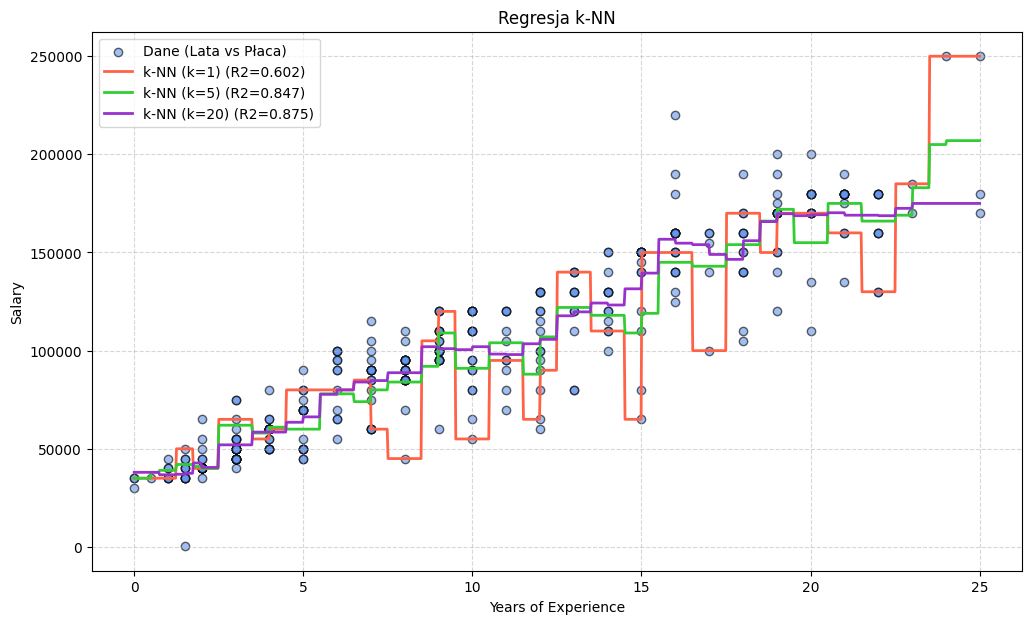

In [77]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline

X_exp = df[['Years of Experience']]
y_salary = df['Salary']

n_neighbors_list = [1, 5, 20]
models = {f'k-NN (k={k})': make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k)) for k in n_neighbors_list}

plt.figure(figsize=(12, 7))
plt.scatter(X_exp, y_salary, color='cornflowerblue', edgecolor='k', alpha=0.6, label='Dane (Lata vs Płaca)')

x_axis = np.linspace(X_exp.min(), X_exp.max(), 1000).reshape(-1, 1)

colors = ['tomato', 'limegreen', 'darkorchid']
for i, (name, model) in enumerate(models.items()):
    model.fit(X_exp, y_salary)

    y_plot_pred = model.predict(x_axis)

    y_all_pred = model.predict(X_exp)
    r2 = r2_score(y_salary, y_all_pred)

    plt.plot(x_axis, y_plot_pred, color=colors[i], label=f'{name} (R2={r2:.3f})', linewidth=2)

plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Regresja k-NN')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Regresja wyższego rzędu jest uzasadniona. Na początku kariery pensja szybciej rośnie zazwyczaj i jest to właśnie liniowe, jednak ze wzrostem lat doświadczenia ten wzrost zwalnia, dodatkowo często pensja osiąga już wysoki poziom i po czasie nie zmienia się aż tak bardzo. Dlatego regresja wyższgo rzędu będzie tutaj lepszym wyborem
